## Tensor Train Model for Pharmacy Desert Risk Prediction
# Week 6 – Tensor Train Network Modeling

# Loading Data

Importing the merged dataset

In [2]:
import pandas as pd
import numpy as np

# Data Importation
# Getting cleaned and merged per state data
df = pd.read_csv("df_final_pharmacy_cleaned.csv")
# Getting Overview
df.head()


,State_y,County,county_fips,year,pharmacies_per_county_year,tot_claims,tot_30day_fills,tot_drug_cost,tot_days_supply,tot_beneficiaries,avg_bene_age,Health_Outcome_Rank,Health_Factor_Rank,labor_force,employed,unemployed,unemployment_rate
0,AK,Aleutians East,2013,2014,0,1543,2515.200000,101236.20,69125,252,72.206522,16.0,16.0,2219,2121,98,4.4
1,AK,Aleutians East,2013,2015,1,1265,2095.733333,87137.34,58674,211,70.535299,16.0,16.0,2472,2395,77,3.1
2,AK,Aleutians East,2013,2016,2,1977,3104.066667,144648.87,84565,250,66.715694,16.0,16.0,2589,2523,66,2.5
3,AK,Aleutians East,2013,2018,2,1451,2550.366667,112767.33,67572,435,69.874315,16.0,16.0,2316,2250,66,2.8
4,AK,Aleutians East,2013,2019,1,92,136.433333,11567.95,2963,42,70.142857,16.0,16.0,2544,2483,61,2.4


# Feature Engineering

Data preprocessing and feature engineering for Tensor Train Network modeling with spatial and tabular features.

# Feature Engineering for Target: Temporal Desert Formation

**Pharmacy Accessibility Pressure (PAP) Index** - measures the beneficiary load per pharmacy by dividing the total number of beneficiaries (tot_beneficiaries) by the total number of pharmacies in the given county. Given as bene_per_pharmacy_PAP

**Temporal Desert Formation (TDF) Feature** - Tracks the percentage change in the **Pharmacy Accessibility Pressure (PAP) Index** across years for each of the counties. Given as access_pressure_change_TDF and such that:

- Negative values = accessibility improved

- Near zero = stable accessibility

- Positive values = worsening accessibility

- Large positive values = rapid deterioration (potential desert formation)


**Desert_Formation_Risk** - Binary feature for a county as either at high risk or low risk of pharmacy desert formation based on the percentage change in the Pharmacy Accessibility Pressure (PAP) Index (≥25% change = High Risk, otherwise Low Risk).

In [3]:
# Creating the Pharmacy Accessibility Pressure Index (PAP)
df["bene_per_pharmacy_PAP"] = (
    df["tot_beneficiaries"] /
    df["pharmacies_per_county_year"]
)

# Creating a lag for Accessibility Pressure Index
df["bene_per_pharmacy_PAP_lag"] = (
    df.groupby("county_fips")["bene_per_pharmacy_PAP"]
      .shift(1)
)


# Creating Temporal Desert Formation Feature
df["access_pressure_change_TDF"] = (
    (df["bene_per_pharmacy_PAP"] - df["bene_per_pharmacy_PAP_lag"])/df["bene_per_pharmacy_PAP_lag"]
)


In [4]:
# Pharmacy Desert Formation Risk Feature

df["Desert_Formation_Risk"] = np.where(
    df["access_pressure_change_TDF"] >= 0.25,
    "High Risk",
    "Low Risk"
)

## Creating Queen Spatial Lag features

In [5]:
%pip install geopandas

In [6]:
# Getting County Geometry Data

import geopandas as gpd

# Importing county level shape file
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
)
print(counties.head())

  STATEFP COUNTYFP  COUNTYNS         GEOIDFQ  GEOID     NAME        NAMELSAD  \
0      01      003  00161527  0500000US01003  01003  Baldwin  Baldwin County   
1      01      069  00161560  0500000US01069  01069  Houston  Houston County   
2      01      005  00161528  0500000US01005  01005  Barbour  Barbour County   
3      01      119  00161585  0500000US01119  01119   Sumter   Sumter County   
4      05      091  00069166  0500000US05091  05091   Miller   Miller County   

  STUSPS STATE_NAME LSAD       ALAND      AWATER  \
0     AL    Alabama   06  4117725048  1132887203   
1     AL    Alabama   06  1501742235     4795415   
2     AL    Alabama   06  2292160151    50523213   
3     AL    Alabama   06  2340898915    24634880   
4     AR   Arkansas   06  1616257232    36848741   

                                            geometry  
0  POLYGON ((-88.02858 30.22676, -88.02399 30.230...  
1  POLYGON ((-85.71209 31.19727, -85.70934 31.198...  
2  POLYGON ((-85.74803 31.61918, -85.7454

In [7]:
# Correcting the county fips in the pharmacy dataset to ensure a leading 0 is added to the fips where necessary
df['county_fips'] = (
    df['county_fips']
    .astype(str)
    .str.zfill(5)
)
# Ensuring data type alignment in counties geometry data
counties['GEOID'] = (
    counties['GEOID']
    .astype(str)
    .str.zfill(5)
)

In [8]:
%pip install libpysal

In [9]:
# Creating Queen's contiguity spatial weights
from libpysal.weights import Queen

w = Queen.from_dataframe(
    counties,
    ids='GEOID'
)

print(w.n)
print(w.neighbors[list(w.neighbors.keys())[0]])

3235
['01097', '01099', '12033', '01053', '01129', '01025']


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 21 islands with ids: 15003, 15007, 69110, 78020, 25007, 53055, 60020, 69085, 66010, 15001, 78010, 78030, 60040, 02016, 69100, 72147, 36085, 69120, 25019, 72049, 60030.
  W.__init__(self, neighbors, ids=ids, **kw)


In [10]:
# Setting up Row Standardized Spatial Weights
w.transform = 'R'

# Variables for spatial lagging
spatial_vars = [

    'access_pressure_change_TDF',

    'tot_claims',

    'tot_drug_cost',

    'unemployment_rate',

    'tot_beneficiaries'
]

# Creating yearly Queen spatial lags for the variables of interest

from libpysal.weights import Queen, lag_spatial


lagged_frames = []


for yr in sorted(df['year'].unique()):

    temp = df[df['year'] == yr].copy()

    # collapsing duplicates per county
    temp = temp.groupby('county_fips', as_index=False).mean(numeric_only=True)

    # merge geometry
    temp = counties[['GEOID', 'geometry']].merge(
        temp,
        left_on='GEOID',
        right_on='county_fips',
        how='inner'
    )

    # ensure unique IDs (CRITICAL)
    temp = temp.drop_duplicates(subset='GEOID')

    temp = temp.sort_values('GEOID').reset_index(drop=True)

    # build weights
    year_w = Queen.from_dataframe(
        temp,
        ids='GEOID'
    )

    year_w.transform = "R"

    for var in spatial_vars:

        temp[f'queen_lag_{var}'] = lag_spatial(
            year_w,
            temp[var].values
        )

    lagged_frames.append(temp)

('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '69110', ' is an island (no neighbors)')
('WARNING: ', '78020', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '60020', ' is an island (no neighbors)')
('WARNING: ', '69085', ' is an island (no neighbors)')
('WARNING: ', '66010', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '78010', ' is an island (no neighbors)')
('WARNING: ', '78030', ' is an island (no neighbors)')
('WARNING: ', '60040', ' is an island (no neighbors)')
('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '69100', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '69120', ' is an island (no neighbors)')
('WARNING:

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


...

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 9 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING:

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


In [11]:
# Combining yearly spatial lag results

spatial_lag_df = pd.concat(
    lagged_frames,
    ignore_index=True
)

print(spatial_lag_df.shape)

# Identifying generated Queen lag columns

queen_cols = [
    c
    for c in spatial_lag_df.columns
    if c.startswith('queen_lag_')
]

print(queen_cols)

# Keeping only keys + spatial lag variables

spatial_lag_df = spatial_lag_df[
    ['county_fips', 'year'] + queen_cols
]

print(spatial_lag_df.head())

# Merging spatial lag variables back to original panel

df = df.merge(
    spatial_lag_df,
    on=['county_fips', 'year'],
    how='left'
)

print(df.shape)

# Checking missing values

print(
    df[queen_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

(22245, 25)
['queen_lag_access_pressure_change_TDF', 'queen_lag_tot_claims', 'queen_lag_tot_drug_cost', 'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries']
  county_fips    year  queen_lag_access_pressure_change_TDF  \
0       01001  2014.0                                   NaN   
1       01003  2014.0                                   NaN   
2       01005  2014.0                                   NaN   
3       01007  2014.0                                   NaN   
4       01009  2014.0                                   NaN   

   queen_lag_tot_claims  queen_lag_tot_drug_cost  queen_lag_unemployment_rate  \
0         582126.000000             4.384596e+07                     8.540000   
1         894515.333333             7.140206e+07                     9.150000   
2         203567.375000             1.173513e+07                     8.050000   
3         727194.041667             5.338642e+07                     7.450000   
4         851820.541667             6.217652e+07  

In [12]:

df.columns

Index(['State_y', 'County', 'county_fips', 'year',
       'pharmacies_per_county_year', 'tot_claims', 'tot_30day_fills',
       'tot_drug_cost', 'tot_days_supply', 'tot_beneficiaries', 'avg_bene_age',
       'Health_Outcome_Rank', 'Health_Factor_Rank', 'labor_force', 'employed',
       'unemployed', 'unemployment_rate', 'bene_per_pharmacy_PAP',
       'bene_per_pharmacy_PAP_lag', 'access_pressure_change_TDF',
       'Desert_Formation_Risk', 'queen_lag_access_pressure_change_TDF',
       'queen_lag_tot_claims', 'queen_lag_tot_drug_cost',
       'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries'],
      dtype='object')

# Modeling - Tensor Train Binary Classification with Spatial Features

## Target and Features

**Target Variable:** `Desert_Formation_Risk` - A binary classification target predicting whether a county has High Risk or Low Risk for pharmacy desert formation based on the Temporal Desert Formation (TDF) feature.
- High Risk: `access_pressure_change_TDF >= 0.25` (worsening accessibility pressure)
- Low Risk: `access_pressure_change_TDF < 0.25` (stable or improving accessibility)

**Features:**

**'tot_claims'** (consumer demand for total number of customers),

**'tot_30day_fills'** (service demand and profitability indicator),

**'tot_drug_cost'** (profitability indicator for cost of drugs bought),

**'tot_beneficiaries'** (consumer demand for total number of customers),

**'avg_bene_age'** (customer characteristic in terms of age),

**'Health_Outcome_Rank'** (the rank of how healthy the county in which a pharmacy is located is),

**'Health_Factor_Rank'** (the rank of the health risks for the county in which a pharmacy is located),

**'unemployment_rate'** (macroeconomic indicator for average purchasing power of population in the county),

**'queen_lag_access_pressure_change_TDF'** (spatial lag of accessibility pressure change using Queen's contiguity),

**'queen_lag_tot_beneficiaries'** (spatial lag of total beneficiaries using Queen's contiguity)

In [13]:
import random
import torch

def set_seed(seed=2):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(2)

# Removing rows with missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Checking column names
df.columns

Index(['State_y', 'County', 'county_fips', 'year',
       'pharmacies_per_county_year', 'tot_claims', 'tot_30day_fills',
       'tot_drug_cost', 'tot_days_supply', 'tot_beneficiaries', 'avg_bene_age',
       'Health_Outcome_Rank', 'Health_Factor_Rank', 'labor_force', 'employed',
       'unemployed', 'unemployment_rate', 'bene_per_pharmacy_PAP',
       'bene_per_pharmacy_PAP_lag', 'access_pressure_change_TDF',
       'Desert_Formation_Risk', 'queen_lag_access_pressure_change_TDF',
       'queen_lag_tot_claims', 'queen_lag_tot_drug_cost',
       'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries'],
      dtype='object')

In [14]:
# Features' Columns
features = [
    'tot_claims',
    'tot_30day_fills',
    'tot_drug_cost',
    'tot_days_supply',
    #'tot_beneficiaries',
    'avg_bene_age',
    'Health_Outcome_Rank',
    'Health_Factor_Rank',
    'unemployment_rate',
    #'queen_lag_access_pressure_change_TDF',
    'queen_lag_tot_claims',
    'queen_lag_tot_drug_cost',
    'queen_lag_unemployment_rate',
    #'queen_lag_tot_beneficiaries'
]

# Target Variable
target = 'Desert_Formation_Risk'

In [15]:
# Setting up features and target
X = df[features].values.astype(np.float32)

# Binary encoding for target: High Risk = 1, Low Risk = 0
y = (df[target] == 'High Risk').astype(np.float32)


## Time-Based Data Partitioning

In [16]:
# Splitting into train and test sets based on target year (pre-2020 for training, 2020+ for testing)
train_mask = df['year'] <= 2020
test_mask = df['year'] > 2020

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print(X_train.shape)
print(X_test.shape)

(5461, 11)
(1072, 11)


In [17]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(5461, 11)
(1072, 11)


## Setting up PyTorch Dataset

In [18]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Reshape y for binary classification with BCELoss
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

y_train = torch.tensor(y_train_enc, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)

# Tensor Train Classifier (Binary Classification)

Binary classification model to predict Desert Formation Risk (High Risk vs Low Risk)

In [19]:
import torch
import torch.nn as nn

class TTLayer(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim,
        rank=4
    ):
        super().__init__()

        self.U = nn.Parameter(
            torch.randn(input_dim, rank)
        )

        self.V = nn.Parameter(
            torch.randn(rank, output_dim)
        )

    def forward(self, x):

        z = x @ self.U
        y = z @ self.V

        return y

In [20]:
class TTClassifier(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.tt = TTLayer(
            input_dim=input_dim,
            output_dim=32,
            rank=4
        )

        self.out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.tt(x)
        x = self.out(x)

        return x

model = TTClassifier(len(features))

In [21]:
print("Model Architecture:")
print(model)

Model Architecture:
TTClassifier(
  (tt): TTLayer()
  (out): Sequential(
    (0): ReLU()
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


## Training

In [22]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

# Use Binary Cross Entropy Loss for binary classification
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 200

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} "
            f"Loss: {epoch_loss/len(train_loader):.6f}"
        )

Epoch   0 Loss: 0.479371
Epoch  10 Loss: 0.427190
Epoch  20 Loss: 0.417032
Epoch  30 Loss: 0.411233
Epoch  40 Loss: 0.409449
Epoch  50 Loss: 0.408948
Epoch  60 Loss: 0.407557
Epoch  70 Loss: 0.406892
Epoch  80 Loss: 0.405028
Epoch  90 Loss: 0.402433
Epoch 100 Loss: 0.400148
Epoch 110 Loss: 0.399951
Epoch 120 Loss: 0.396010
Epoch 130 Loss: 0.395096
Epoch 140 Loss: 0.396850
Epoch 150 Loss: 0.396593
Epoch 160 Loss: 0.393001
Epoch 170 Loss: 0.391855
Epoch 180 Loss: 0.393601
Epoch 190 Loss: 0.391826


## Evaluation

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

with torch.no_grad():
    preds_prob = model(X_test).numpy().flatten()

# Convert probabilities to binary predictions (threshold = 0.5)
preds = (preds_prob >= 0.5).astype(int)

actuals = y_test.numpy().flatten().astype(int)

accuracy = accuracy_score(actuals, preds)
precision = precision_score(actuals, preds, zero_division=0)
recall = recall_score(actuals, preds, zero_division=0)
f1 = f1_score(actuals, preds, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(actuals, preds))
print("\nClassification Report:")
print(classification_report(actuals, preds, target_names=['Low Risk', 'High Risk']))

Accuracy : 0.8405
Precision: 0.2692
Recall   : 0.0440
F1-Score : 0.0757

Confusion Matrix:
[[894  19]
 [152   7]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.85      0.98      0.91       913
   High Risk       0.27      0.04      0.08       159

    accuracy                           0.84      1072
   macro avg       0.56      0.51      0.49      1072
weighted avg       0.77      0.84      0.79      1072



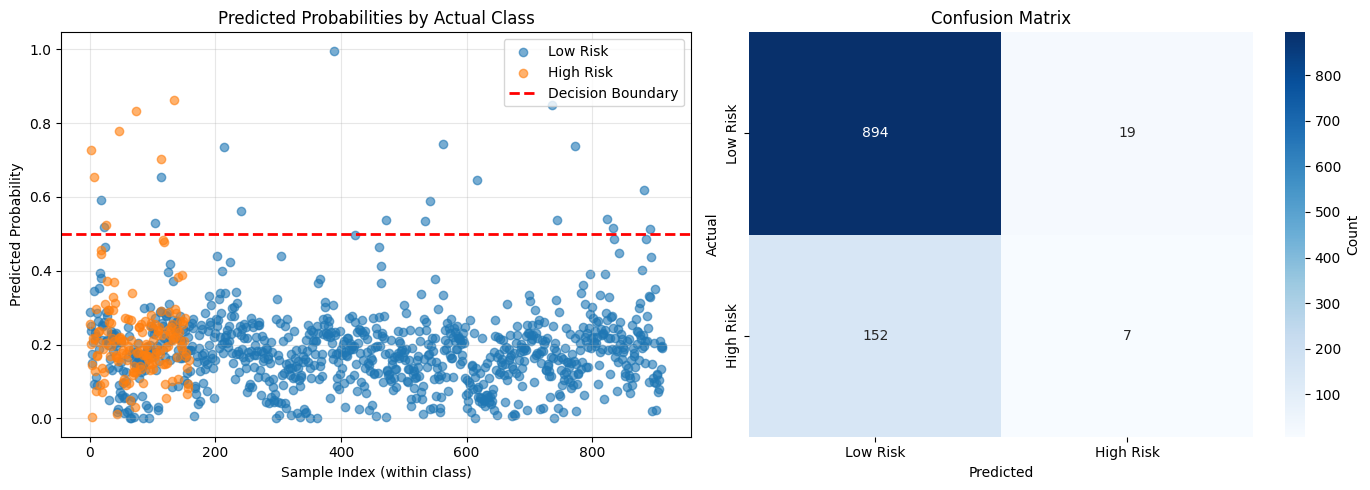

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted Probabilities by Actual Class
ax1 = axes[0]
for label in [0, 1]:
    mask = actuals == label
    label_name = 'High Risk' if label == 1 else 'Low Risk'
    ax1.scatter(
        range(np.sum(mask)),
        preds_prob[mask],
        alpha=0.6,
        label=label_name
    )
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
ax1.set_xlabel("Sample Index (within class)")
ax1.set_ylabel("Predicted Probability")
ax1.set_title("Predicted Probabilities by Actual Class")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[1]
cm = confusion_matrix(actuals, preds)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax2,
    cbar_kws={'label': 'Count'}
)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")
ax2.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [25]:
# Feature Importance Calculation using Permutation Importance for Classification

# Baseline accuracy
baseline_accuracy = accuracy_score(actuals, preds)
print("Baseline Accuracy:", baseline_accuracy)

import pandas as pd
import numpy as np

feature_importance = {}

X_test_np = X_test.numpy()

for i, feature in enumerate(features):

    X_permuted = X_test_np.copy()

    np.random.shuffle(
        X_permuted[:, i]
    )

    X_permuted_tensor = torch.tensor(
        X_permuted,
        dtype=torch.float32
    )

    with torch.no_grad():
        perm_preds_prob = (
            model(X_permuted_tensor)
            .numpy()
            .flatten()
        )

    perm_preds = (perm_preds_prob >= 0.5).astype(int)

    perm_accuracy = accuracy_score(
        actuals,
        perm_preds
    )

    importance = (
        abs(baseline_accuracy - perm_accuracy)
    )

    feature_importance[feature] = importance

Baseline Accuracy: 0.8404850746268657


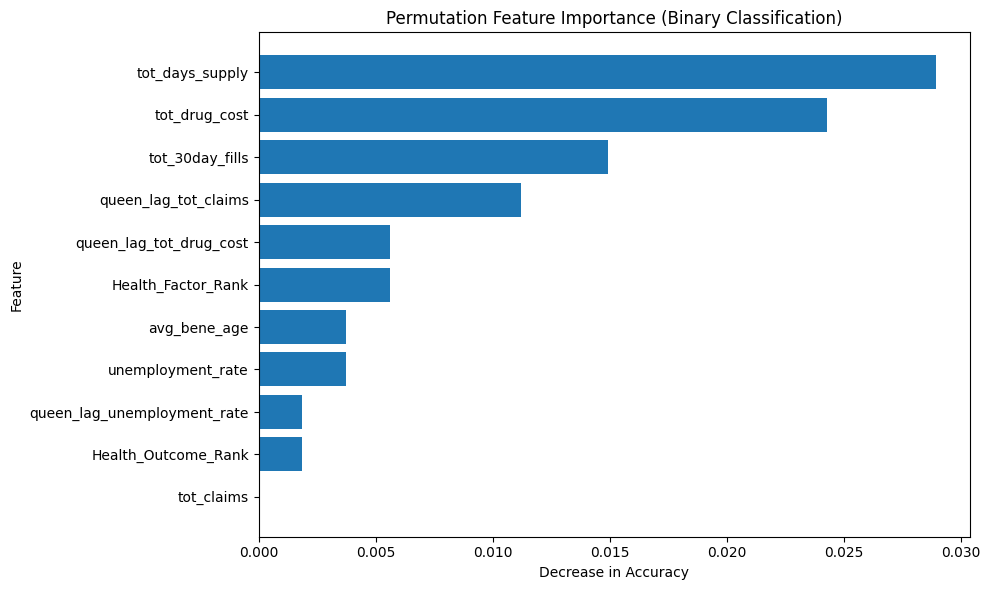

In [26]:
# Feature Importance Visualization
importance_df = pd.DataFrame({
    "Feature": feature_importance.keys(),
    "Importance": feature_importance.values()
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Decrease in Accuracy")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Binary Classification)")

plt.tight_layout()
plt.show()

# All Models'Comparisons

In [28]:
# Loading model comparison data
model_comp_df = pd.read_csv("model_performance_comparisons.csv")
# Getting Overview
model_comp_df.head()

,Model,Type,Accuracy,Precision,Recall
0,XGBoost,Temporal Model,0.82,0.75,0.82
1,LSTM,Temporal Model,0.83,0.64,0.83
2,ST-GNN,Spatial Temporal Model,0.72,0.26,0.25
3,HGNN,Higher Order Network Model,0.72,0.23,0.26
4,TT,Higher Order Network Model,0.84,0.35,0.06


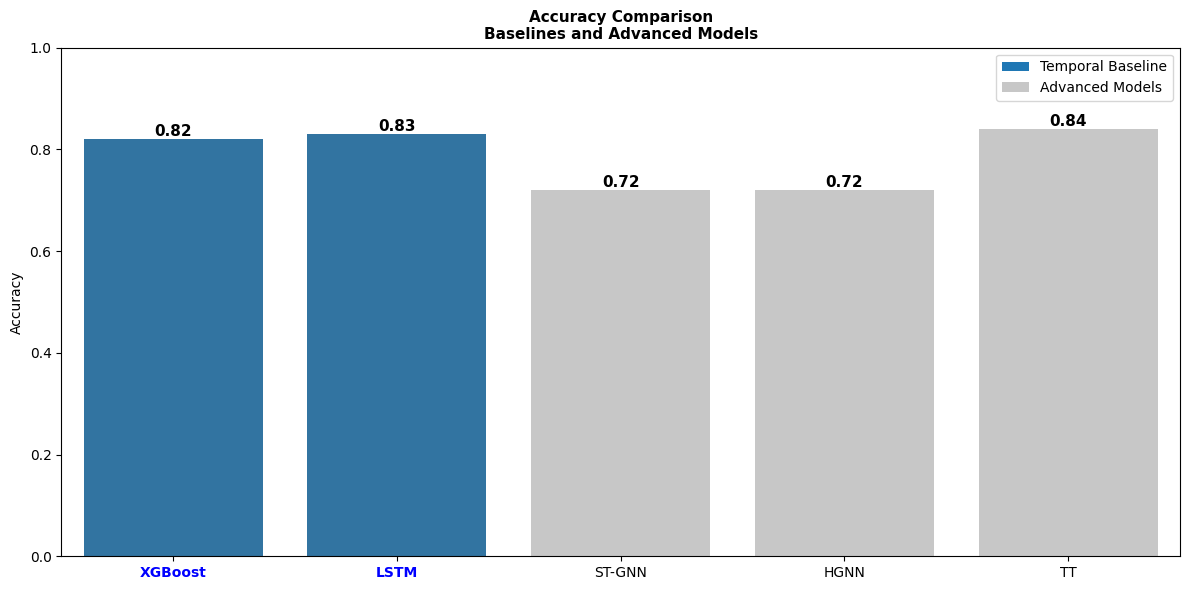

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Highlighting temporal baseline models
highlight_models = ["XGBoost", "LSTM"]

palette = {
    "XGBoost": "#1f77b4",   # Baseline
    "LSTM": "#1f77b4",      # Baseline
    "ST-GNN": "#c7c7c7",
    "HGNN": "#c7c7c7",
    "TT": "#c7c7c7"
}

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=model_comp_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=palette,
    dodge=False,
    legend=False
)

# Adding accuracy values on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Highlighting baseline model labels
for tick in ax.get_xticklabels():
    if tick.get_text() in highlight_models:
        tick.set_fontweight("bold")
        tick.set_color("blue")

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_title(
    "Accuracy Comparison\nBaselines and Advanced Models",
    fontsize=11,
    fontweight="bold"
)

# Legend
legend_handles = [
    Patch(facecolor="#1f77b4", label="Temporal Baseline"),
    Patch(facecolor="#c7c7c7", label="Advanced Models")
]
ax.legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

## Tensor Train Modeling Summary

This notebook trained and evaluated a Tensor Train Network model for pharmacy desert risk prediction.

Completed steps:
• Created PAP, TDF, and Desert Formation Risk target label.
• Created Queen contiguity spatial lag features.
• Prepared high-dimensional tabular and spatial input features.
• Built a Tensor Train classifier using a TT layer, ReLU activation, fully connected layers, and sigmoid output.
• Trained the model using BCELoss and Adam optimizer with learning rate 0.001.
• Evaluated the model using accuracy, precision, recall, F1-score, confusion matrix, classification report, and predicted probability plot.
• Generated permutation feature importance and model comparison visualizations.

Key finding:
Tensor Train achieved the highest overall accuracy, but High-Risk recall was very weak. The model predicted many actual High-Risk cases as Low Risk, showing the effect of class imbalance. Therefore, Tensor Train was not the best practical model even though its accuracy was high.

Next step:
The final project comparison shows that XGBoost remained the best practical baseline because it provided better balanced performance and interpretability.
